# 📊 Análise Visual — Imóveis SP

Nove gráficos salvos em `.jpg` cobrindo correlação, distribuição, comparação de modelos, resíduos, features e análise exploratória.

In [28]:
# ── Importações Gerais ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp_stats
import os

# ── Scikit-learn: Validação e Modelos ─────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge

# ── Scikit-learn: Métricas ────────────────────────────────────────
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
# ── Pipeline base ─────────────────────────────────────────────────
df = pd.read_csv('../data/imoveis_sp_limpo.csv', encoding='utf-8-sig')
df = df.dropna()
df = df[(df['preco_venda'] >= df['preco_venda'].quantile(0.01)) &
        (df['preco_venda'] <= df['preco_venda'].quantile(0.99))]

X = df.drop('preco_venda', axis=1)
y = np.log1p(df['preco_venda'])
X_enc = pd.get_dummies(X, columns=['bairro', 'tipo_imovel'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=2,
                           max_features='sqrt', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(f'R² Random Forest: {r2_score(y_test, pred_rf):.4f}')

R² Random Forest: 0.8840


## 1 · Matriz de Correlação

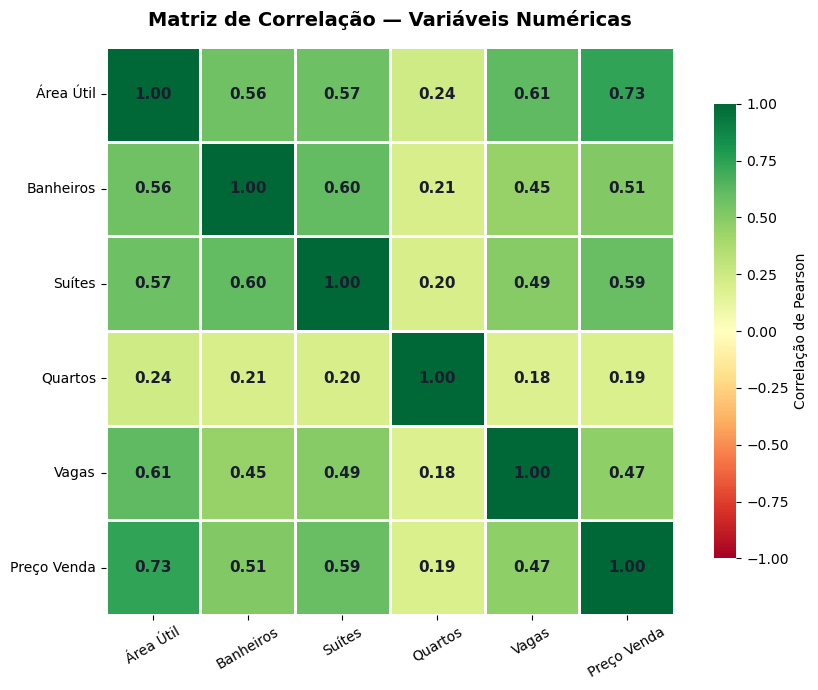

In [27]:
num_cols = ['area_util','banheiros','suites','quartos','vagas_garagem','preco_venda']
labels   = ['Área Útil','Banheiros','Suítes','Quartos','Vagas','Preço Venda']
corr = df[num_cols].corr()
corr.index = labels; corr.columns = labels

# salva tabela
corr.round(3).to_csv(
    '../data/tabela_correlacao.csv',
    encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
sns.heatmap(corr, mask=None, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=1, linecolor='white',
            square=True, annot_kws={'size':11,'color':'#1a1d2e','weight':'bold'},
            ax=ax, cbar_kws={'shrink':0.8,'label':'Correlação de Pearson'})
ax.set_title('Matriz de Correlação — Variáveis Numéricas', pad=15, fontweight='bold', fontsize=14)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('../graficos/plot1_correlacao.jpg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 2 · Distribuição do Preço: Original vs Log

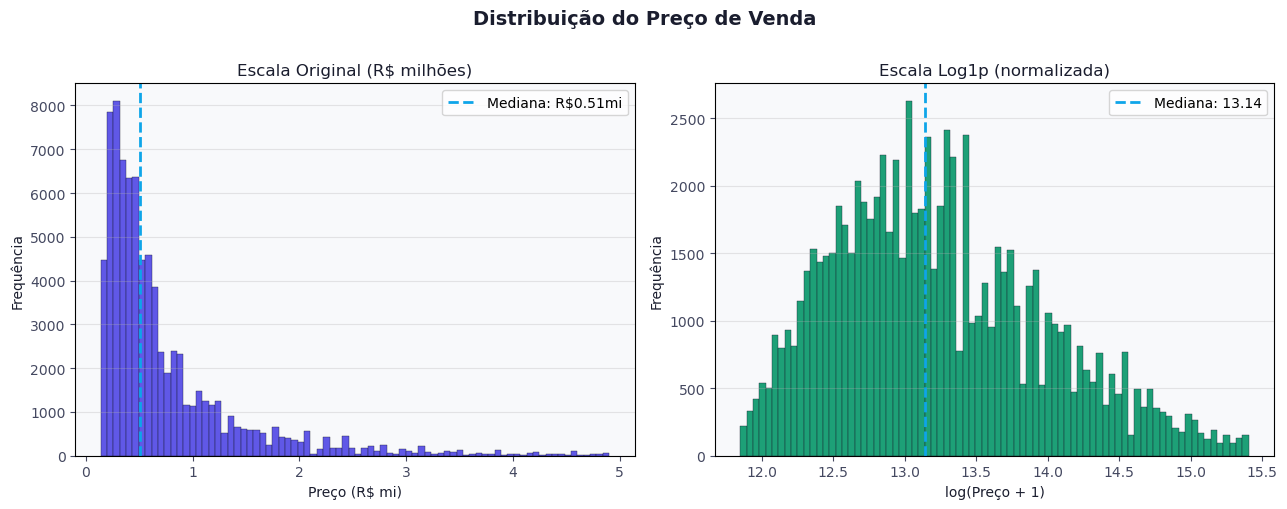

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.patch.set_facecolor('white')
fig.suptitle('Distribuição do Preço de Venda',
             fontsize=14, fontweight='bold', y=1.01, color='#1a1d2e')

for ax in axes:
    ax.set_facecolor('#f8f9fb')
    ax.grid(True, axis='y', alpha=0.3)

    ax.tick_params(colors='#444860')
    ax.xaxis.label.set_color('#1a1d2e')
    ax.yaxis.label.set_color('#1a1d2e')
    ax.title.set_color('#1a1d2e')

axes[0].hist(
    df['preco_venda']/1e6,
    bins=80,
    color='#4f46e5',   # mais escuro
    alpha=0.9,
    edgecolor='#1a1d2e',
    linewidth=0.3
)

axes[0].set_title('Escala Original (R$ milhões)', color='#1a1d2e')
axes[0].set_xlabel('Preço (R$ mi)', color='#1a1d2e')
axes[0].set_ylabel('Frequência', color='#1a1d2e')

axes[0].axvline(
    df['preco_venda'].median()/1e6,
    color='#0ea5e9',
    lw=2,
    ls='--',
    label=f'Mediana: R${df["preco_venda"].median()/1e6:.2f}mi'
)

axes[0].legend()

axes[1].hist(
    np.log1p(df['preco_venda']),
    bins=80,
    color='#059669',   # verde mais escuro
    alpha=0.9,
    edgecolor='#1a1d2e',
    linewidth=0.3
)

axes[1].set_title('Escala Log1p (normalizada)', color='#1a1d2e')
axes[1].set_xlabel('log(Preço + 1)', color='#1a1d2e')
axes[1].set_ylabel('Frequência', color='#1a1d2e')

axes[1].axvline(
    np.log1p(df['preco_venda']).median(),
    color='#0ea5e9',
    lw=2,
    ls='--',
    label=f'Mediana: {np.log1p(df["preco_venda"]).median():.2f}'
)

axes[1].legend()

plt.tight_layout()

plt.savefig(
    '../graficos/plot2_distribuicao_preco.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 3 · Comparação de modelos

## 3A · Comparação de Modelos — Espaço Log

> Todas as métricas (R², MAE, RMSE) calculadas sobre `log1p(preço)`. Comparáveis entre si na mesma escala.

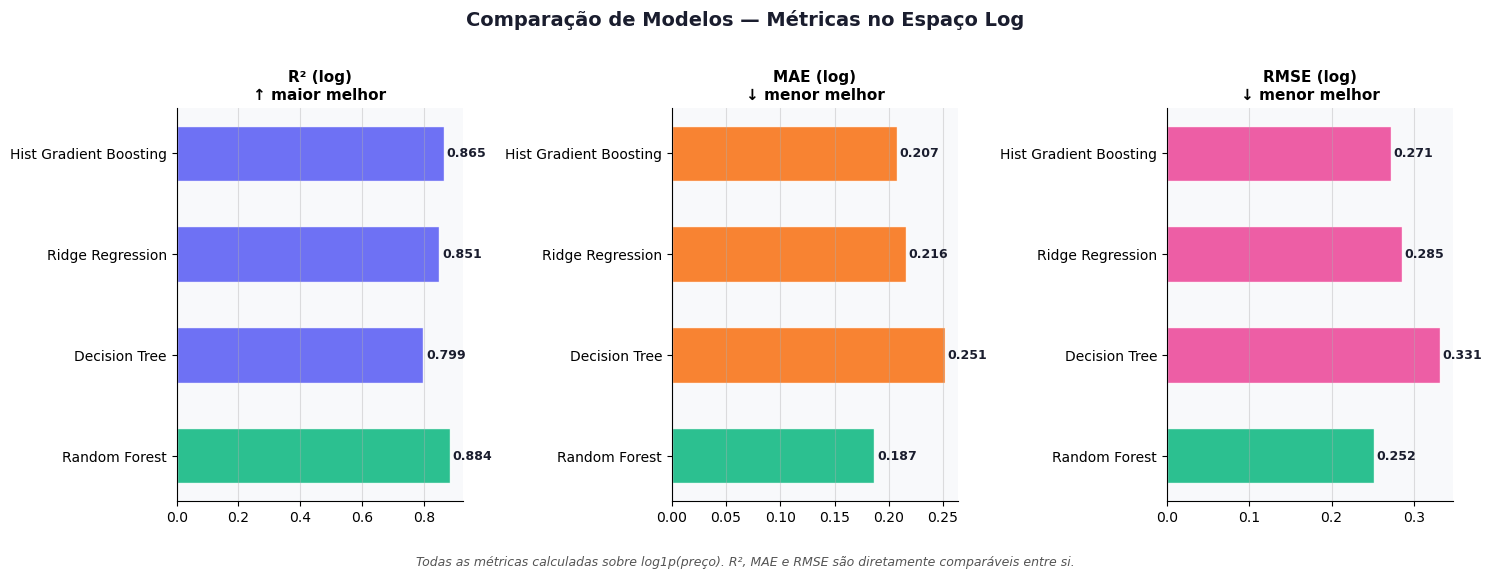

In [39]:
models_dict = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ),

    'Ridge Regression': Ridge(alpha=1.0),

    'Hist Gradient Boosting': HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.1,
        max_iter=80,
        random_state=42
    ),
}
results, preds_log = {}, {}
for name, model in models_dict.items():
    model.fit(X_train, y_train)
    pl = model.predict(X_test)
    pr, yr = np.expm1(pl), np.expm1(y_test.values)
    preds_log[name] = pl
    results[name] = {
        'R² (log)':   r2_score(y_test, pl),
        'MAE (log)':  mean_absolute_error(y_test, pl),
        'RMSE (log)': np.sqrt(mean_squared_error(y_test, pl)),
        'R² (real)':   r2_score(yr, pr),
        'MAE (R$k)':   mean_absolute_error(yr, pr) / 1000,
        'RMSE (R$k)':  np.sqrt(mean_squared_error(yr, pr)) / 1000,
    }
res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Modelo'})

def make_metric_plot(res_df, metrics, base_colors, better, title, note, fname):
    C3, BEST = '#10b981', '#10b981'
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
    fig.patch.set_facecolor('white')
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02, color='#1a1d2e')
    for ax, metric, bc, b in zip(axes, metrics, base_colors, better):
        ax.set_facecolor('#f8f9fb'); ax.spines[['top','right']].set_visible(False)
        vals = res_df[metric].values.astype(float)
        best_idx = int(np.argmax(vals) if b=='max' else np.argmin(vals))
        clrs = [BEST if i==best_idx else bc for i in range(len(vals))]
        ax.barh(res_df['Modelo'], vals, color=clrs, alpha=0.88, edgecolor='white', height=0.55)
        ax.set_title(f'{metric}\n{"↑ maior melhor" if b=="max" else "↓ menor melhor"}', fontweight='bold', fontsize=11)
        ax.grid(True, axis='x', alpha=0.4)
        for i, v in enumerate(vals):
            fmt = f'{v:.3f}' if abs(v) < 10 else f'{v:.0f}'
            ax.text(v + max(abs(vals))*0.01, i, fmt, va='center', color='#1a1d2e', fontsize=9, fontweight='bold')
    fig.text(0.5, -0.05, note, ha='center', fontsize=9, color='#555', style='italic')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

make_metric_plot(res_df,
    metrics=['R² (log)', 'MAE (log)', 'RMSE (log)'],
    base_colors=['#5b5ef4', '#f97316', '#ec4899'],
    better=['max', 'min', 'min'],
    title='Comparação de Modelos — Métricas no Espaço Log',
    note='Todas as métricas calculadas sobre log1p(preço). R², MAE e RMSE são diretamente comparáveis entre si.',
    fname='../graficos/plot3A_metricas_log.jpg')


## 3B · Comparação de Modelos — Valores Reais (R$)

> Métricas convertidas de volta para reais. MAE e RMSE em R$k. Ridge com R² negativo indica colapso do modelo linear.

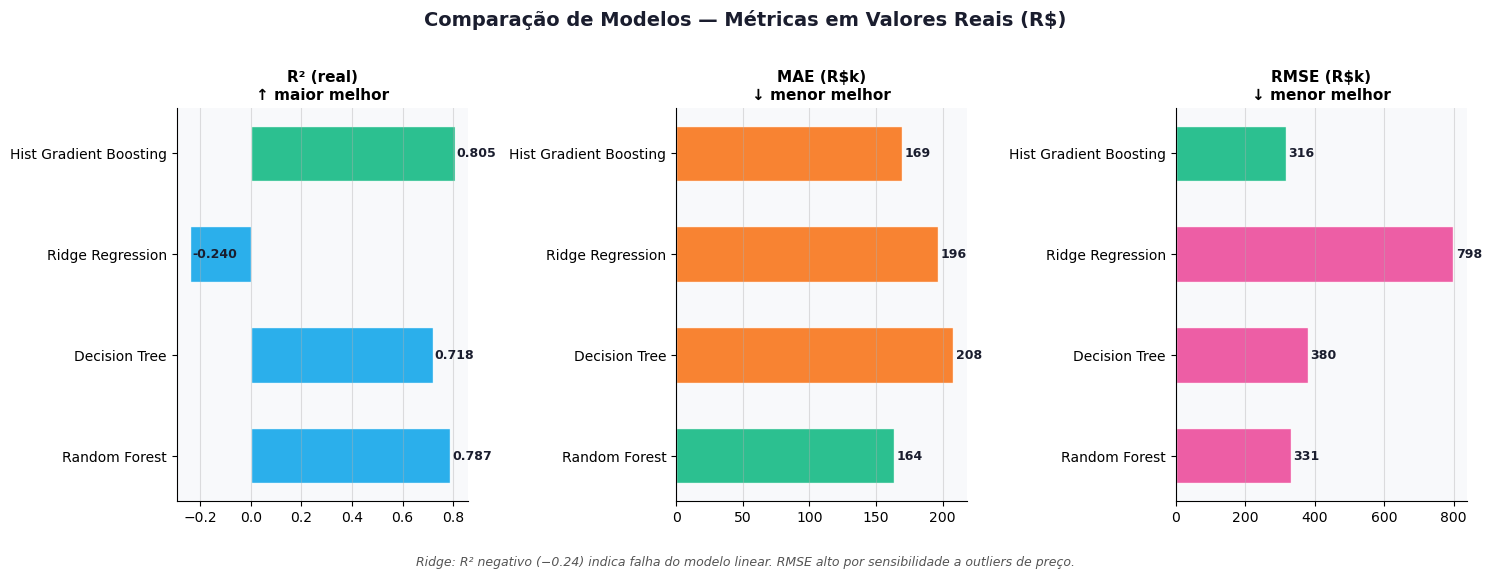

In [19]:
make_metric_plot(res_df,
    metrics=['R² (real)', 'MAE (R$k)', 'RMSE (R$k)'],
    base_colors=['#0ea5e9', '#f97316', '#ec4899'],
    better=['max', 'min', 'min'],
    title='Comparação de Modelos — Métricas em Valores Reais (R$)',
    note='Ridge: R² negativo (−0.24) indica falha do modelo linear. RMSE alto por sensibilidade a outliers de preço.',
    fname='../graficos/plot3B_metricas_real.jpg')


## 4 · Real vs Predito (Densidade)

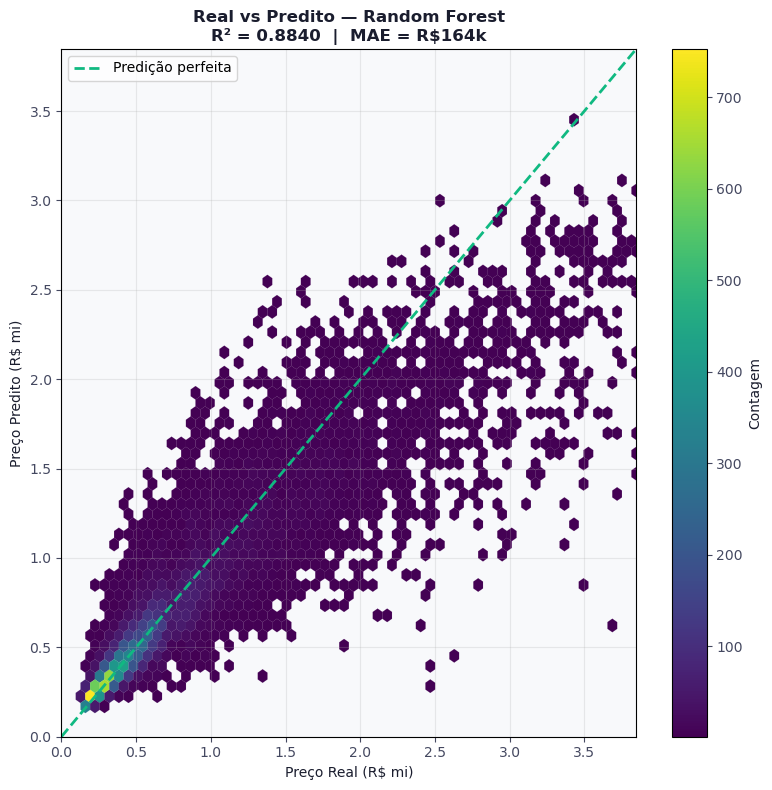

In [37]:
y_real = np.expm1(y_test.values)
p_real = np.expm1(pred_rf)

lim_max = np.percentile(y_real, 99)

fig, ax = plt.subplots(figsize=(8, 8))

# fundo claro consistente
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fb')

hb = ax.hexbin(
    y_real/1e6,
    p_real/1e6,
    gridsize=60,
    cmap='viridis',   # melhor que plasma no claro
    mincnt=1,
    extent=[0, lim_max/1e6, 0, lim_max/1e6],
    linewidths=0.1
)

cb = fig.colorbar(hb, ax=ax, label='Contagem')
cb.ax.yaxis.label.set_color('#1a1d2e')
cb.ax.tick_params(colors='#444860')

lim = lim_max/1e6

# linha de referência
ax.plot(
    [0, lim],
    [0, lim],
    '--',
    color='#10b981',
    lw=2,
    label='Predição perfeita'
)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

ax.set_xlabel('Preço Real (R$ mi)', color='#1a1d2e')
ax.set_ylabel('Preço Predito (R$ mi)', color='#1a1d2e')

ax.set_title(
    f'Real vs Predito — Random Forest\n'
    f'R² = {r2_score(y_test, pred_rf):.4f}  |  '
    f'MAE = R${mean_absolute_error(y_real, p_real)/1000:.0f}k',
    fontweight='bold',
    color='#1a1d2e'
)

ax.tick_params(colors='#444860')
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(
    '../graficos/plot4_real_vs_predito.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 5 · Análise de Resíduos

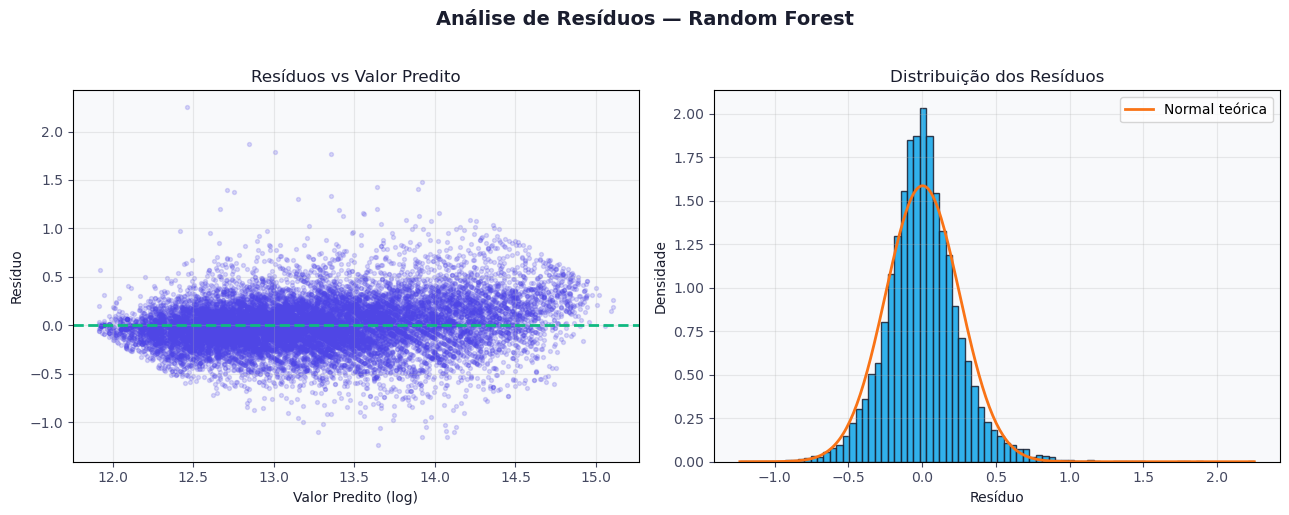

In [36]:
residuos = y_test.values - pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# fundo claro consistente
fig.patch.set_facecolor('white')
fig.suptitle(
    'Análise de Resíduos — Random Forest',
    fontsize=14,
    fontweight='bold',
    y=1.02,
    color='#1a1d2e'
)

for ax in axes:
    ax.set_facecolor('#f8f9fb')
    ax.grid(True, alpha=0.25)
    ax.tick_params(colors='#444860')

# ─────────────────────────────────────────────
# 1) resíduos vs predito
# ─────────────────────────────────────────────
axes[0].scatter(
    pred_rf,
    residuos,
    alpha=0.2,
    s=8,
    color='#4f46e5'
)

axes[0].axhline(0, color='#10b981', lw=2, ls='--')

axes[0].set_xlabel('Valor Predito (log)', color='#1a1d2e')
axes[0].set_ylabel('Resíduo', color='#1a1d2e')
axes[0].set_title('Resíduos vs Valor Predito', color='#1a1d2e')

# ─────────────────────────────────────────────
# 2) distribuição dos resíduos
# ─────────────────────────────────────────────
axes[1].hist(
    residuos,
    bins=80,
    color='#0ea5e9',
    alpha=0.85,
    edgecolor='#1a1d2e',
    density=True
)

xr = np.linspace(residuos.min(), residuos.max(), 300)

axes[1].plot(
    xr,
    sp_stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    color='#f97316',
    lw=2,
    label='Normal teórica'
)

axes[1].set_xlabel('Resíduo', color='#1a1d2e')
axes[1].set_ylabel('Densidade', color='#1a1d2e')
axes[1].set_title('Distribuição dos Resíduos', color='#1a1d2e')

axes[1].legend()

plt.tight_layout()
plt.savefig(
    '../graficos/plot5_residuos.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 6 · Top 20 Features — Importância

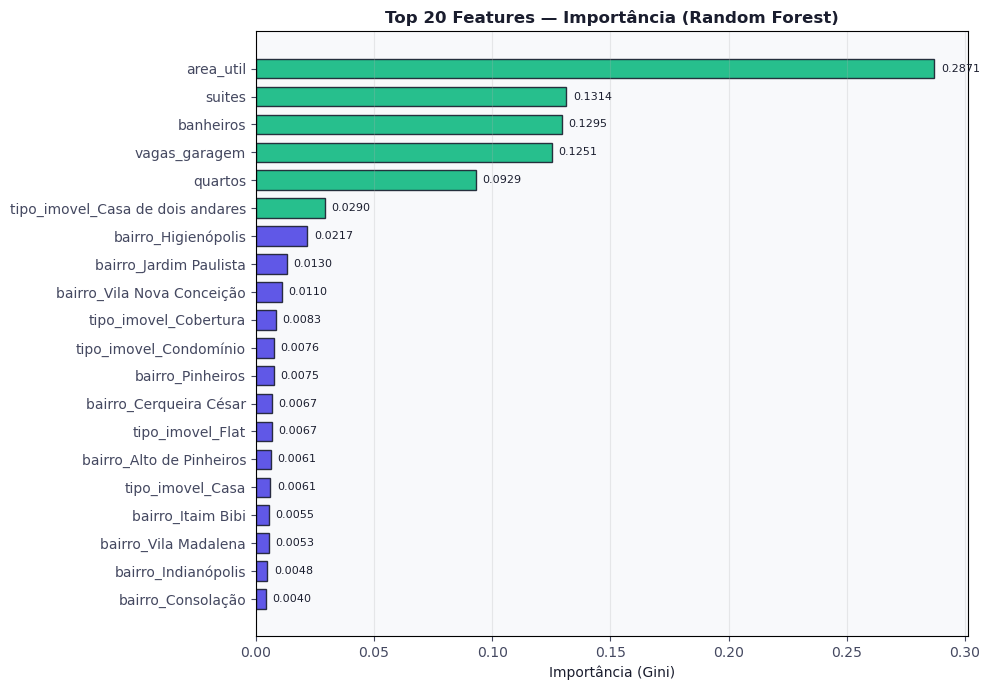

In [42]:
importances = pd.Series(rf.feature_importances_, index=X_enc.columns)
top20 = importances.sort_values(ascending=True).tail(20)

os.makedirs('../data', exist_ok=True)

# tabela das 20 features mais importantes
top20_df = (
    top20.sort_values(ascending=False)
         .reset_index()
)

top20_df.columns = ['Feature', 'Importancia']

top20_df.to_csv(
    '../data/tabela_importancia_features.csv',
    index=False,
    encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(10, 7))

# fundo claro consistente
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fb')

# cores mais legíveis
clrs = ['#4f46e5' if v < top20.quantile(0.7) else '#10b981'
        for v in top20.values]

bars = ax.barh(
    top20.index,
    top20.values,
    color=clrs,
    alpha=0.9,
    edgecolor='#1a1d2e',
    height=0.7
)

ax.set_title(
    'Top 20 Features — Importância (Random Forest)',
    fontweight='bold',
    color='#1a1d2e'
)

ax.set_xlabel('Importância (Gini)', color='#1a1d2e')

ax.tick_params(colors='#444860')

ax.grid(True, axis='x', alpha=0.25)

# valores nas barras
for bar, v in zip(bars, top20.values):
    ax.text(
        v + top20.values.max() * 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{v:.4f}',
        va='center',
        color='#1a1d2e',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    '../graficos/plot6_importancia_features.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 7 · Preço por Tipo de Imóvel

C:\Users\bibif\AppData\Local\Temp\ipykernel_22828\2125472759.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


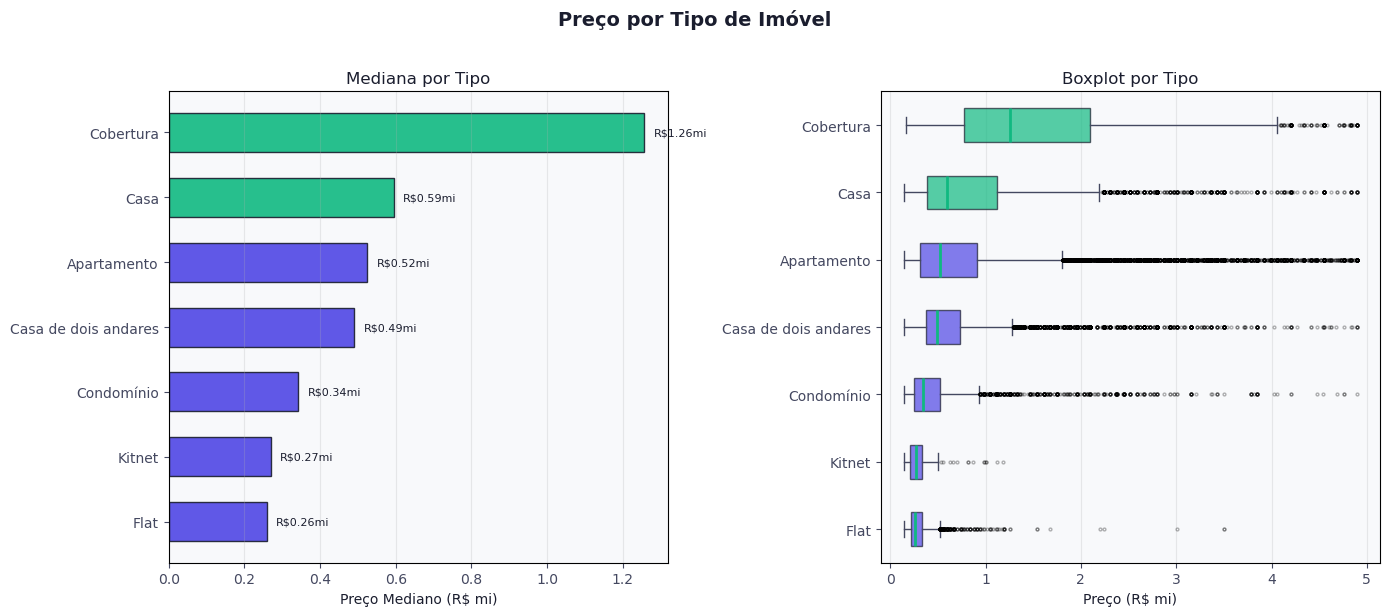

In [34]:
tipo_counts = df['tipo_imovel'].value_counts()
tipos_top = tipo_counts[tipo_counts > 200].index.tolist()
df_tipo = df[df['tipo_imovel'].isin(tipos_top)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# fundo claro consistente
fig.patch.set_facecolor('white')
fig.suptitle(
    'Preço por Tipo de Imóvel',
    fontsize=14,
    fontweight='bold',
    y=1.02,
    color='#1a1d2e'
)

med = (
    df_tipo.groupby('tipo_imovel')['preco_venda']
    .median()
    .sort_values(ascending=True) / 1e6
)

clrs = ['#4f46e5' if v < med.quantile(0.7) else '#10b981'
        for v in med.values]

# ─────────────────────────────────────────────
# 1) mediana por tipo
# ─────────────────────────────────────────────
axes[0].set_facecolor('#f8f9fb')
axes[0].grid(True, axis='x', alpha=0.25)

axes[0].barh(
    med.index,
    med.values,
    color=clrs,
    edgecolor='#1a1d2e',
    height=0.6,
    alpha=0.9
)

axes[0].set_xlabel('Preço Mediano (R$ mi)', color='#1a1d2e')
axes[0].set_title('Mediana por Tipo', color='#1a1d2e')
axes[0].tick_params(colors='#444860')

for i, (idx, v) in enumerate(med.items()):
    axes[0].text(
        v + med.max() * 0.02,
        i,
        f'R${v:.2f}mi',
        va='center',
        color='#1a1d2e',
        fontsize=8
    )

# ─────────────────────────────────────────────
# 2) boxplot
# ─────────────────────────────────────────────
axes[1].set_facecolor('#f8f9fb')
axes[1].grid(True, axis='x', alpha=0.25)

data_box = [
    df_tipo[df_tipo['tipo_imovel'] == t]['preco_venda'].values / 1e6
    for t in med.index
]

bp = axes[1].boxplot(
    data_box,
    vert=False,
    patch_artist=True,
    labels=med.index,
    medianprops={'color': '#10b981', 'lw': 2},
    whiskerprops={'color': '#444860'},
    capprops={'color': '#444860'},
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3}
)

for patch, c in zip(bp['boxes'], clrs):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
    patch.set_edgecolor('#1a1d2e')

axes[1].set_xlabel('Preço (R$ mi)', color='#1a1d2e')
axes[1].set_title('Boxplot por Tipo', color='#1a1d2e')
axes[1].tick_params(colors='#444860')

plt.tight_layout()

plt.savefig(
    '../graficos/plot7_preco_por_tipo.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 8 · Top 15 Bairros por Preço Mediano

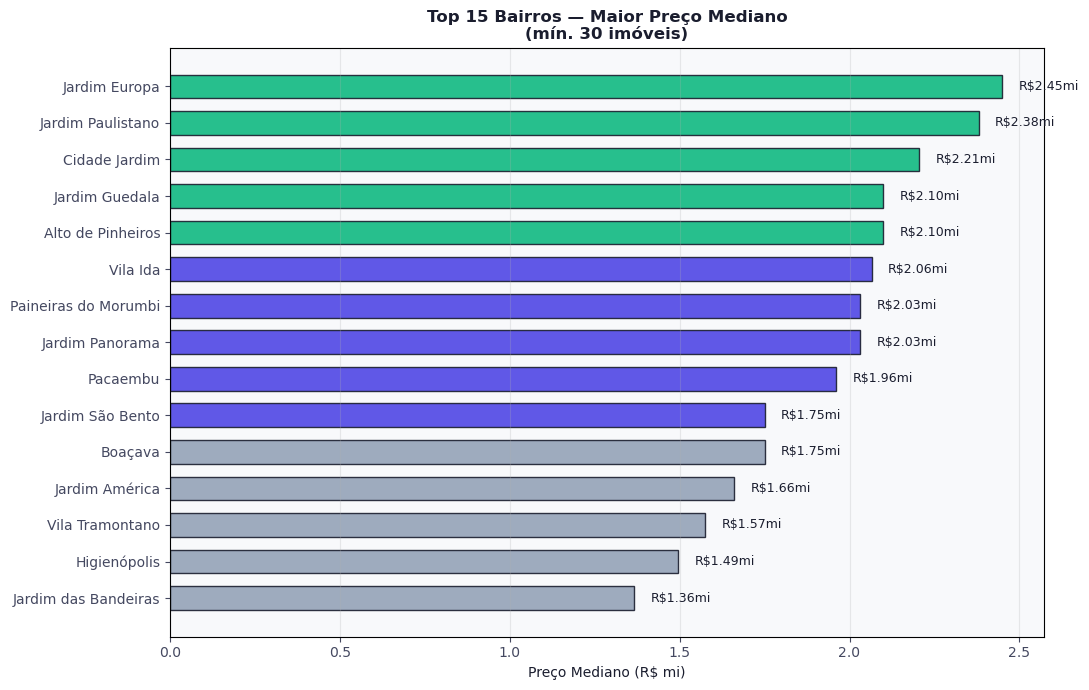

In [43]:
bairro_med = (
    df.groupby('bairro')['preco_venda']
    .agg(['median', 'count'])
)

bairro_med = bairro_med[bairro_med['count'] >= 30] \
    .sort_values('median', ascending=False) \
    .head(15)

bairro_med['median'] = bairro_med['median'] / 1e6

bairro_tabela = (
    df.groupby('bairro')['preco_venda']
      .agg(['median', 'count'])
)

bairro_tabela = (
    bairro_tabela[bairro_tabela['count'] >= 30]
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

bairro_tabela.columns = [
    'Bairro',
    'Preco_Mediano_R$',
    'Quantidade_Imoveis'
]

bairro_tabela.to_csv(
    '../data/tabela_top_bairros.csv',
    index=False,
    encoding='utf-8-sig'
)

fig, ax = plt.subplots(figsize=(11, 7))

# fundo claro consistente
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fb')

ax.grid(True, axis='x', alpha=0.25)

# cores com significado (top vs resto)
colors = [
    '#10b981' if i < 5 else '#4f46e5' if i < 10 else '#94a3b8'
    for i in range(len(bairro_med))
]

bars = ax.barh(
    bairro_med.index[::-1],
    bairro_med['median'][::-1],
    color=colors[::-1],
    edgecolor='#1a1d2e',
    alpha=0.9,
    height=0.65
)

ax.set_xlabel('Preço Mediano (R$ mi)', color='#1a1d2e')

ax.set_title(
    'Top 15 Bairros — Maior Preço Mediano\n(mín. 30 imóveis)',
    fontweight='bold',
    color='#1a1d2e'
)

ax.tick_params(colors='#444860')

# valores nas barras
for bar, v in zip(bars, bairro_med['median'][::-1].values):
    ax.text(
        v + bairro_med['median'].max() * 0.02,
        bar.get_y() + bar.get_height()/2,
        f'R${v:.2f}mi',
        va='center',
        color='#1a1d2e',
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    '../graficos/plot8_top_bairros.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 9 · Preço vs Área Útil

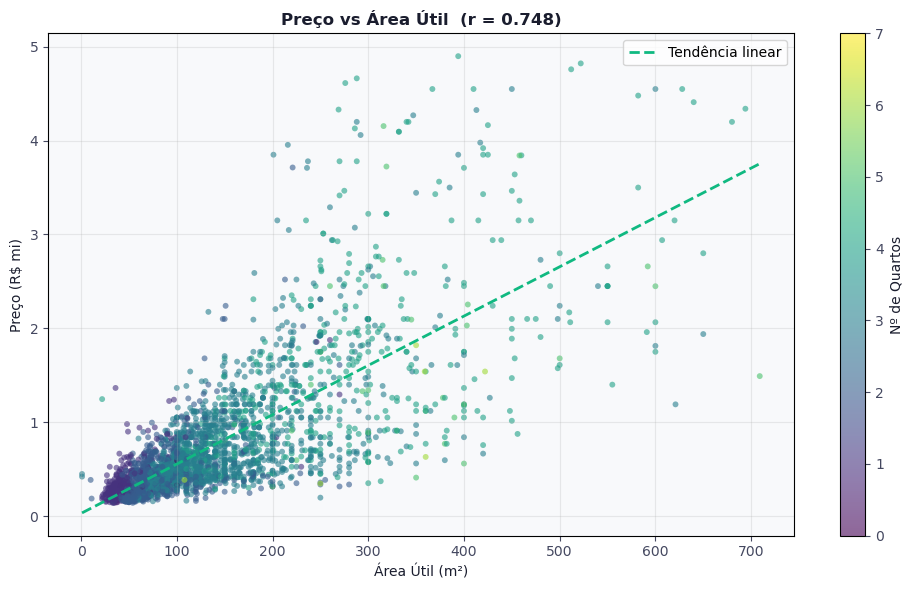

In [32]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

# fundo claro consistente
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fb')

ax.grid(True, alpha=0.25)

sc = ax.scatter(
    sample['area_util'],
    sample['preco_venda'] / 1e6,
    c=sample['quartos'],
    cmap='viridis',
    alpha=0.6,
    s=18,
    edgecolors='none'
)

cb = fig.colorbar(sc, ax=ax, label='Nº de Quartos')
cb.ax.yaxis.label.set_color('#1a1d2e')
cb.ax.tick_params(colors='#444860')

# regressão linear
z = np.polyfit(sample['area_util'], sample['preco_venda'] / 1e6, 1)
xs = np.linspace(sample['area_util'].min(), sample['area_util'].max(), 200)

ax.plot(
    xs,
    np.poly1d(z)(xs),
    color='#10b981',
    lw=2,
    ls='--',
    label='Tendência linear'
)

# correlação
r, _ = sp_stats.pearsonr(
    sample['area_util'],
    sample['preco_venda']
)

ax.set_title(
    f'Preço vs Área Útil  (r = {r:.3f})',
    fontweight='bold',
    color='#1a1d2e'
)

ax.set_xlabel('Área Útil (m²)', color='#1a1d2e')
ax.set_ylabel('Preço (R$ mi)', color='#1a1d2e')

ax.tick_params(colors='#444860')

ax.legend()

plt.tight_layout()

plt.savefig(
    '../graficos/plot9_preco_vs_area.jpg',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## 10 · Exemplos Práticos — O Modelo na Vida Real

> 15 imóveis reais do conjunto de teste divididos em 3 grupos: predições ótimas (erro < 5%), regulares (10–20%) e ruins (> 40%).

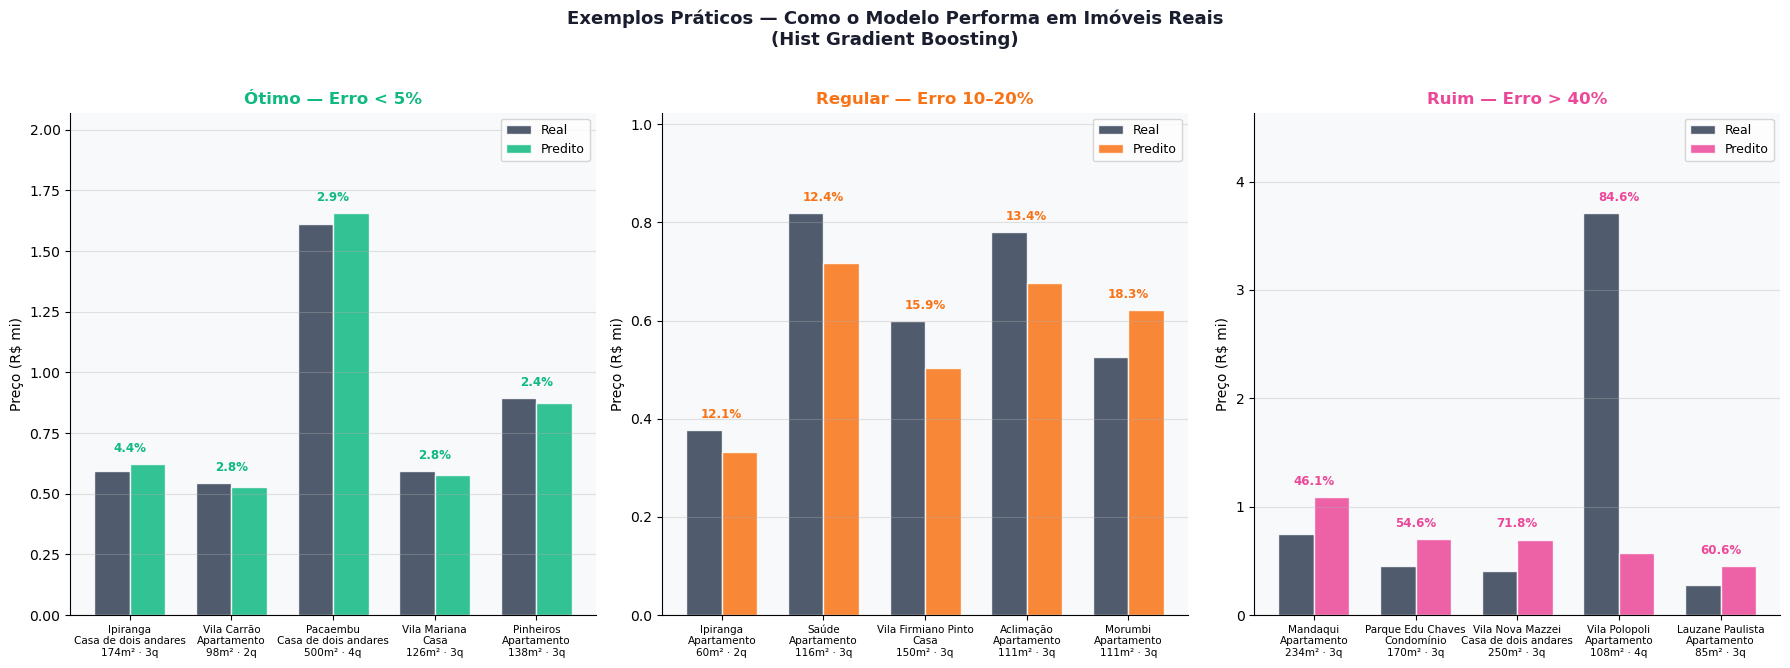

In [31]:
df_test = df.loc[X_test.index].copy()
df_test['pred_real'] = np.expm1(preds_log['Hist Gradient Boosting'])
df_test['erro_pct']  = abs(df_test['preco_venda'] - df_test['pred_real']) / df_test['preco_venda'] * 100

bons   = df_test[df_test['erro_pct'] < 5].sample(5, random_state=7)
medios = df_test[(df_test['erro_pct'] >= 10) & (df_test['erro_pct'] < 20)].sample(5, random_state=7)
ruins  = df_test[df_test['erro_pct'] > 40].sample(5, random_state=7)

C3, C4, C5 = '#10b981', '#f97316', '#ec4899'
cat_colors = {'Ótimo': C3, 'Regular': C4, 'Ruim': C5}
cat_labels  = {'Ótimo': 'Erro < 5%', 'Regular': 'Erro 10–20%', 'Ruim': 'Erro > 40%'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor('white')
fig.suptitle('Exemplos Práticos — Como o Modelo Performa em Imóveis Reais\n(Hist Gradient Boosting)',
             fontsize=13, fontweight='bold', y=1.02, color='#1a1d2e')

for ax, (cat, grp) in zip(axes, [('Ótimo', bons), ('Regular', medios), ('Ruim', ruins)]):
    ax.set_facecolor('#f8f9fb'); ax.spines[['top','right']].set_visible(False)
    color = cat_colors[cat]
    labels = [f"{row['bairro']}\n{row['tipo_imovel']}\n{row['area_util']:.0f}m² · {int(row['quartos'])}q"
              for _, row in grp.iterrows()]
    real = grp['preco_venda'].values / 1e6
    pred = grp['pred_real'].values   / 1e6
    x, w = np.arange(len(labels)), 0.35
    ax.bar(x - w/2, real, w, label='Real',    color='#334155', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, pred, w, label='Predito', color=color,     alpha=0.85, edgecolor='white')
    for i, (r, p) in enumerate(zip(real, pred)):
        ep = abs(r - p) / r * 100
        ax.text(x[i], max(r, p) + max(max(real),max(pred))*0.03,
                f'{ep:.1f}%', ha='center', fontsize=8.5, color=color, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5, ha='center')
    ax.set_ylabel('Preço (R$ mi)')
    ax.set_title(f'{cat} — {cat_labels[cat]}', fontweight='bold', color=color, fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.35)
    ax.set_ylim(0, max(max(real), max(pred)) * 1.25)

plt.tight_layout()
plt.savefig('../graficos/plot10_exemplos_praticos.jpg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 11 · Onde o Modelo Erra Mais? — Erro por Faixa de Preço


> Análise de como o erro percentual varia entre imóveis baratos e caros. Imóveis de luxo (> 2M) tendem a ter maior dispersão.

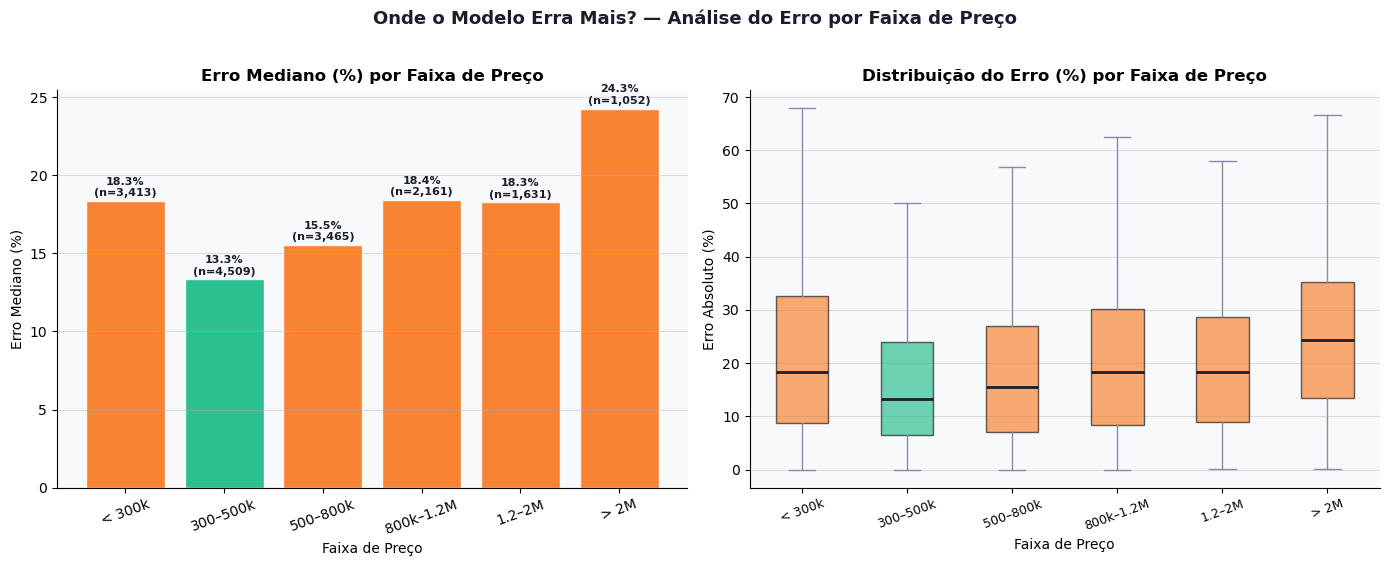

In [41]:
df_test['faixa'] = pd.cut(df_test['preco_venda']/1e6,
    bins=[0, 0.3, 0.5, 0.8, 1.2, 2, 99],
    labels=['< 300k','300–500k','500–800k','800k–1.2M','1.2–2M','> 2M'])
faixa_stats = df_test.groupby('faixa', observed=True)['erro_pct'].agg(['median','mean','count']).reset_index()

C3, C4, C5 = '#10b981', '#f97316', '#ec4899'
bar_colors = [C3 if v < 15 else (C4 if v < 25 else C5) for v in faixa_stats['median']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')
fig.suptitle('Onde o Modelo Erra Mais? — Análise do Erro por Faixa de Preço',
             fontsize=13, fontweight='bold', y=1.02, color='#1a1d2e')

ax = axes[0]
ax.set_facecolor('#f8f9fb'); ax.spines[['top','right']].set_visible(False)
bars = ax.bar(faixa_stats['faixa'].astype(str), faixa_stats['median'],
              color=bar_colors, alpha=0.88, edgecolor='white')
for bar, v, n in zip(bars, faixa_stats['median'], faixa_stats['count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}%\n(n={n:,})', ha='center', fontsize=8, fontweight='bold', color='#1a1d2e')
ax.set_title('Erro Mediano (%) por Faixa de Preço', fontweight='bold')
ax.set_xlabel('Faixa de Preço'); ax.set_ylabel('Erro Mediano (%)')
ax.grid(True, axis='y', alpha=0.4); ax.tick_params(axis='x', rotation=20)

ax2 = axes[1]
ax2.set_facecolor('#f8f9fb'); ax2.spines[['top','right']].set_visible(False)
data_box = [df_test[df_test['faixa']==f]['erro_pct'].values for f in faixa_stats['faixa']]
bp = ax2.boxplot(data_box, patch_artist=True, showfliers=False,
                 medianprops={'color':'#1a1d2e','lw':2},
                 whiskerprops={'color':'#888aaa'}, capprops={'color':'#888aaa'})
for patch, c in zip(bp['boxes'], bar_colors): patch.set_facecolor(c); patch.set_alpha(0.6)
ax2.set_xticklabels(faixa_stats['faixa'].astype(str), rotation=20, fontsize=9)
ax2.set_title('Distribuição do Erro (%) por Faixa de Preço', fontweight='bold')
ax2.set_xlabel('Faixa de Preço'); ax2.set_ylabel('Erro Absoluto (%)')
ax2.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../graficos/plot11_erro_por_faixa.jpg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
